In [28]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.random import default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from matplotlib.ticker import SymmetricalLogLocator # For symmetric log scales

import pandas as pd

from project.networks.cbgt import ModelParams, ThalamusParams, BGParams, CBGT
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display, HTML

# Change font of plots
use_latex_fonts()

# Import Data

### Summary Statistics

Importing the data generated in `scripts\cortical dynamics\suite1.ipynb`

In [29]:
summary_stats = load_results('suite1_summary.csv', '../../data/cortical dynamics') 
summary_stats_bypass = load_results('suite1_bypass_summary.csv', '../../data/cortical dynamics')


Loaded: ..\..\data\cortical dynamics\suite1_summary.csv
Loaded: ..\..\data\cortical dynamics\suite1_bypass_summary.csv


In [30]:
display(HTML("<h1 style='font-size:25px'>Summary statistics with cortex</h1>"))
summary_stats.head(5)

,coherence,noise_std,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct RT std CI High (ms),Inverse Efficiency,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin
exp_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,49.44,0.24,...,1.32,49.44,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0
1,1.0,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,49.45,0.25,...,1.41,49.45,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0
2,1.0,0.500,100.0,0.0,96.3,100.0,-7.13,7.13,49.82,0.26,...,1.45,49.82,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0
3,0.3,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,62.54,0.35,...,2.12,62.54,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0
4,0.3,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,62.85,0.58,...,3.40,62.85,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.0


In [31]:
display(HTML("<h1 style='font-size:25px'>Summary statistics bypassing cortex</h1>"))
summary_stats_bypass.head(5)

,coherence,noise_std,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct RT std CI High (ms),Inverse Efficiency,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin
exp_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,37.58,0.25,...,1.37,37.58,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
1,1.0,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,38.00,0.30,...,1.69,38.00,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
2,1.0,0.500,100.0,0.0,96.3,100.0,-7.13,7.13,38.38,0.41,...,2.35,38.38,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
3,0.3,0.125,100.0,0.0,96.3,100.0,-7.13,7.13,46.75,0.60,...,4.58,46.75,100.0,0.0,0.0,0.0,0.0,3.7,0.048,0.002
4,0.3,0.250,100.0,0.0,96.3,100.0,-7.13,7.13,48.93,1.37,...,9.06,48.93,100.0,0.0,0.0,0.0,0.0,3.7,0.070,0.002


The model paramaters are carefully designed not to give rise to any premature decision. For completeness, this can quickly be verified.

In [32]:
print('Amount of premature decision with cortex:', summary_stats['Premature (%)'].sum())
print('Amount of premature decision without cortex:', summary_stats_bypass['Premature (%)'].sum())

Amount of premature decision with cortex: 0.0
Amount of premature decision without cortex: 0.0


As expected, no premature decisions.

### Trial data

Importing trial data

In [33]:
# Index by trial_id
trial_data = load_results('suite1_trials.csv', '../../data/cortical dynamics', index_col = 'trial_id') 
trial_data_bypass = load_results('suite1_bypass_trials.csv', '../../data/cortical dynamics', index_col = 'trial_id')


Loaded: ..\..\data\cortical dynamics\suite1_trials.csv
Loaded: ..\..\data\cortical dynamics\suite1_bypass_trials.csv


In [34]:
display(HTML("<h1 style='font-size:25px'>Trial data with cortex</h1>"))
trial_data.head(5)


,exp_id,stim_info.direction,stim_info.coherence,stim_info.strength,stim_info.noise_std,stim_info.tau,decision_info.Decision,decision_info.Accurate,decision_info.RT (ms),decision_info.Outcome,decision_info.PD Variability,trial_info.model_seed,trial_info.master_seed,trial_info.decision_threshold,trial_info.max_time (s)
trial_id,,,,,,,,,,,,,,,
0,0,1,1.0,1,0.125,0.01,1.0,True,48.0,Correct Decision,0.031098,1,1,0.7,1
1,0,0,1.0,1,0.125,0.01,0.0,True,50.0,Correct Decision,0.032941,1,1,0.7,1
2,0,1,1.0,1,0.125,0.01,1.0,True,48.0,Correct Decision,0.031811,1,1,0.7,1
3,0,0,1.0,1,0.125,0.01,0.0,True,51.0,Correct Decision,0.033137,1,1,0.7,1
4,0,1,1.0,1,0.125,0.01,1.0,True,48.0,Correct Decision,0.032506,1,1,0.7,1


In [35]:
display(HTML("<h1 style='font-size:25px'>Trial data bypassing cortex</h1>"))
trial_data_bypass.head(5)

,exp_id,stim_info.direction,stim_info.coherence,stim_info.strength,stim_info.noise_std,stim_info.tau,decision_info.Decision,decision_info.Accurate,decision_info.RT (ms),decision_info.Outcome,decision_info.PD Variability,trial_info.model_seed,trial_info.master_seed,trial_info.decision_threshold,trial_info.max_time (s)
trial_id,,,,,,,,,,,,,,,
0,0,1,1.0,1,0.125,0.01,1.0,True,37.0,Correct Decision,0.031153,1,1,0.7,1
1,0,0,1.0,1,0.125,0.01,0.0,True,39.0,Correct Decision,0.032051,1,1,0.7,1
2,0,1,1.0,1,0.125,0.01,1.0,True,37.0,Correct Decision,0.031087,1,1,0.7,1
3,0,0,1.0,1,0.125,0.01,0.0,True,38.0,Correct Decision,0.032819,1,1,0.7,1
4,0,1,1.0,1,0.125,0.01,1.0,True,37.0,Correct Decision,0.031087,1,1,0.7,1


# Plotting Data

Plotting relevant summary statistics

### Accuracy, PD variability and mistakes vs coherence

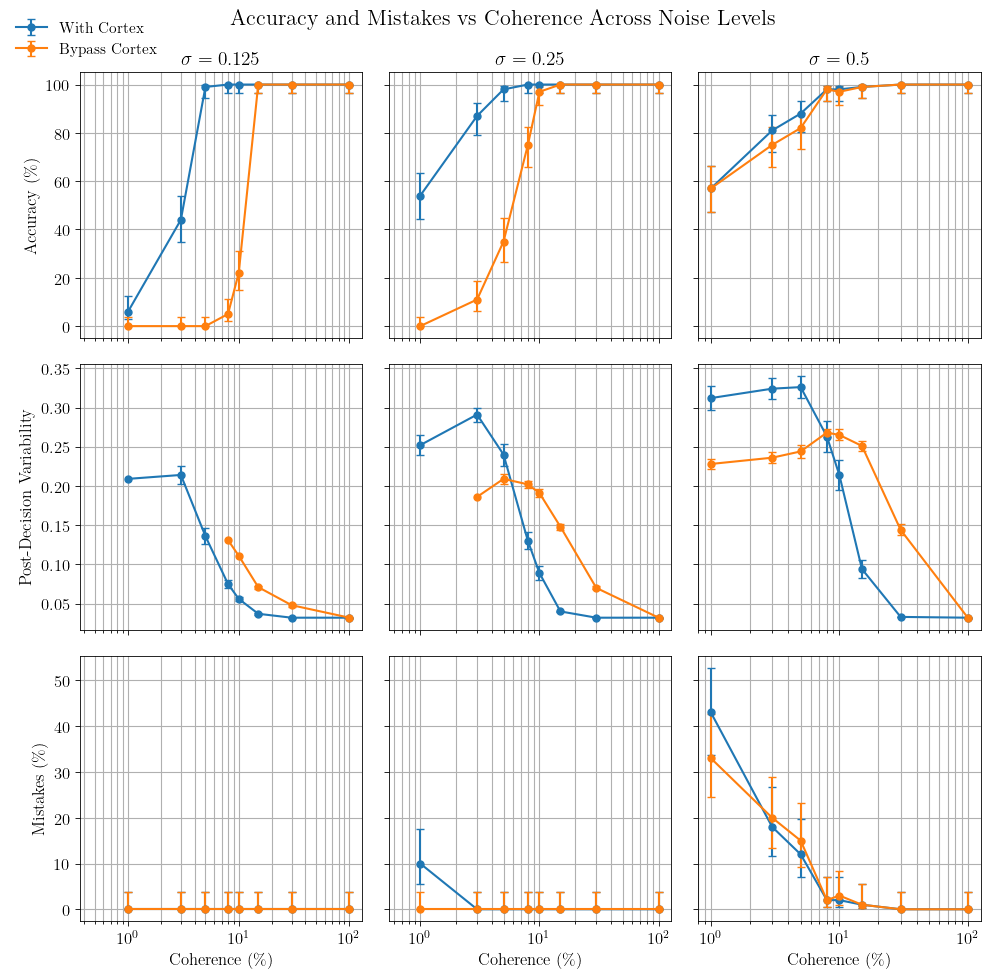

Saved: ..\..\figures\cortical dynamics\suite1\Accuracy and Mistakes vs Coherence.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Accuracy and Mistakes vs Coherence.png


In [36]:
# ===== Split data by noise level =====
# With cortex
df_0125 = summary_stats[summary_stats['noise_std'] == 0.125]
df_025 = summary_stats[summary_stats['noise_std'] == 0.25]
df_05 = summary_stats[summary_stats['noise_std'] == 0.5]

# Bypass cortex
df_0125_bypass = summary_stats_bypass[summary_stats_bypass['noise_std'] == 0.125]
df_025_bypass = summary_stats_bypass[summary_stats_bypass['noise_std'] == 0.25]
df_05_bypass = summary_stats_bypass[summary_stats_bypass['noise_std'] == 0.5]


# ==== Get mean and confidence intervals for each noise level ====
# --- Accuracy ---
acc_0125, acc_err_0125 = get_CI(df_0125, metric='Accuracy (%)') 
acc_025, acc_err_025 = get_CI(df_025, metric='Accuracy (%)') 
acc_05, acc_err_05 = get_CI(df_05, metric='Accuracy (%)') 

acc_0125_bypass, acc_err_0125_bypass = get_CI(df_0125_bypass, metric='Accuracy (%)') 
acc_025_bypass, acc_err_025_bypass = get_CI(df_025_bypass, metric='Accuracy (%)') 
acc_05_bypass, acc_err_05_bypass = get_CI(df_05_bypass, metric='Accuracy (%)') 

# --- Post-decision variability ---
pdv_0125, pdv_err_0125 = get_CI(df_0125, metric='Mean PD Variability')
pdv_025, pdv_err_025 = get_CI(df_025, metric='Mean PD Variability')
pdv_05, pdv_err_05 = get_CI(df_05, metric='Mean PD Variability')

pdv_0125_bypass, pdv_err_0125_bypass = get_CI(df_0125_bypass, metric='Mean PD Variability')
pdv_025_bypass, pdv_err_025_bypass = get_CI(df_025_bypass, metric='Mean PD Variability')
pdv_05_bypass, pdv_err_05_bypass = get_CI(df_05_bypass, metric='Mean PD Variability')

# --- Mistakes ---
mistakes_0125, mistakes_err_0125 = get_CI(df_0125, metric='Wrong Decision (%)')
mistakes_025, mistakes_err_025 = get_CI(df_025, metric='Wrong Decision (%)')
mistakes_05, mistakes_err_05 = get_CI(df_05, metric='Wrong Decision (%)')

mistakes_0125_bypass, mistakes_err_0125_bypass = get_CI(df_0125_bypass, metric='Wrong Decision (%)')
mistakes_025_bypass, mistakes_err_025_bypass = get_CI(df_025_bypass, metric='Wrong Decision (%)')
mistakes_05_bypass, mistakes_err_05_bypass = get_CI(df_05_bypass, metric='Wrong Decision (%)')

# ==== Plotting ====
coherences = summary_stats['coherence'].unique()*100
fig, ax = plt.subplots(3, 3,  figsize= (figure_size('triple')), subplot_kw={"xscale": "log"}, sharex = 'col', sharey = 'row')


# Accuracy
ax[0,0].errorbar(x = coherences, y = acc_0125, yerr = acc_err_0125, fmt='o-', capsize = 3, markersize = 5, label='With Cortex')
ax[0,0].errorbar(x = coherences, y = acc_0125_bypass, yerr = acc_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5, label='Bypass Cortex')
ax[0,0].set_title('$\sigma = 0.125$')
ax[0,0].set_ylabel('Accuracy (\%)')
ax[0,0].grid(which = 'both')

ax[0,1].errorbar(x = coherences, y = acc_025, yerr = acc_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].errorbar(x = coherences, y = acc_025_bypass, yerr = acc_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].set_title('$\sigma = 0.25$')
ax[0,1].grid(which = 'both')

ax[0,2].errorbar(x = coherences, y = acc_05, yerr = acc_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].errorbar(x = coherences, y = acc_05_bypass, yerr = acc_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].set_title('$\sigma = 0.5$')
ax[0,2].grid(which = 'both')

# Post-decision variability

ax[1,0].errorbar(x = coherences, y = pdv_0125, yerr = pdv_err_0125, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].errorbar(x = coherences, y = pdv_0125_bypass, yerr = pdv_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].set_ylabel('Post-Decision Variability')
ax[1,0].grid(which = 'both')

ax[1,1].errorbar(x = coherences, y = pdv_025, yerr = pdv_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].errorbar(x = coherences, y = pdv_025_bypass, yerr = pdv_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].grid(which = 'both')

ax[1,2].errorbar(x = coherences, y = pdv_05, yerr = pdv_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].errorbar(x = coherences, y = pdv_05_bypass, yerr = pdv_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].grid(which = 'both')


# Mistakes
ax[2,0].errorbar(x = coherences, y = mistakes_0125, yerr = mistakes_err_0125, fmt='o-', capsize = 3, markersize = 5)
ax[2,0].errorbar(x = coherences, y = mistakes_0125_bypass, yerr = mistakes_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[2,0].set_xlabel('Coherence (\%)')
ax[2,0].set_ylabel('Mistakes (\%)')
ax[2,0].grid(which = 'both')

ax[2,1].errorbar(x = coherences, y = mistakes_025, yerr = mistakes_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[2,1].errorbar(x = coherences, y = mistakes_025_bypass, yerr = mistakes_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[2,1].set_xlabel('Coherence (\%)')
ax[2,1].grid(which = 'both')

ax[2,2].errorbar(x = coherences, y = mistakes_05, yerr = mistakes_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[2,2].errorbar(x = coherences, y = mistakes_05_bypass, yerr = mistakes_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[2,2].set_xlabel('Coherence (\%)')
ax[2,2].grid(which = 'both')


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy and Mistakes vs Coherence Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Accuracy and Mistakes vs Coherence', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

Extracting numerical values for accuracy

In [37]:
# ==== DataFrame: accuracy by coherence and noise level ====
accuracy_with_cortex = summary_stats[['coherence', 'noise_std', 'Accuracy (%)']].copy()
accuracy_with_cortex['Cortex'] = 'With cortex'

accuracy_without_cortex = summary_stats_bypass[['coherence', 'noise_std', 'Accuracy (%)']].copy()
accuracy_without_cortex['Cortex'] = 'Without cortex'

accuracy_long = pd.concat([accuracy_with_cortex, accuracy_without_cortex], ignore_index=True)
accuracy_long['Coherence (%)'] = accuracy_long['coherence'] * 100
accuracy_long['Condition'] = accuracy_long.apply(
    lambda row: f"{row['Cortex']}, sigma = {row['noise_std']:g}",
    axis=1,
)

accuracy_table = (
    accuracy_long
    .pivot_table(index='Coherence (%)', columns='Condition', values='Accuracy (%)', aggfunc='mean')
    .reset_index()
    .sort_values('Coherence (%)')
)

accuracy_table = accuracy_table[
    ['Coherence (%)']
    + [
        f'{cortex}, sigma = {noise:g}'
        for noise in sorted(accuracy_long['noise_std'].unique())
        for cortex in ['With cortex', 'Without cortex']
    ]
].round(2)
accuracy_table.columns.name = None

accuracy_table

,Coherence (%),"With cortex, sigma = 0.125","Without cortex, sigma = 0.125","With cortex, sigma = 0.25","Without cortex, sigma = 0.25","With cortex, sigma = 0.5","Without cortex, sigma = 0.5"
0,1.0,6.0,0.0,54.0,0.0,57.0,57.0
1,3.0,44.0,0.0,87.0,11.0,81.0,75.0
2,5.0,99.0,0.0,98.0,35.0,88.0,82.0
3,8.0,100.0,5.0,100.0,75.0,98.0,98.0
4,10.0,100.0,22.0,100.0,97.0,98.0,97.0
5,15.0,100.0,100.0,100.0,100.0,99.0,99.0
6,30.0,100.0,100.0,100.0,100.0,100.0,100.0
7,100.0,100.0,100.0,100.0,100.0,100.0,100.0


##### Supplementary figures

From looking at the data, it appears meaningful to plot post-decision variability vs accuracy, as the PD variability appears to show accuracy-dependent behavior.

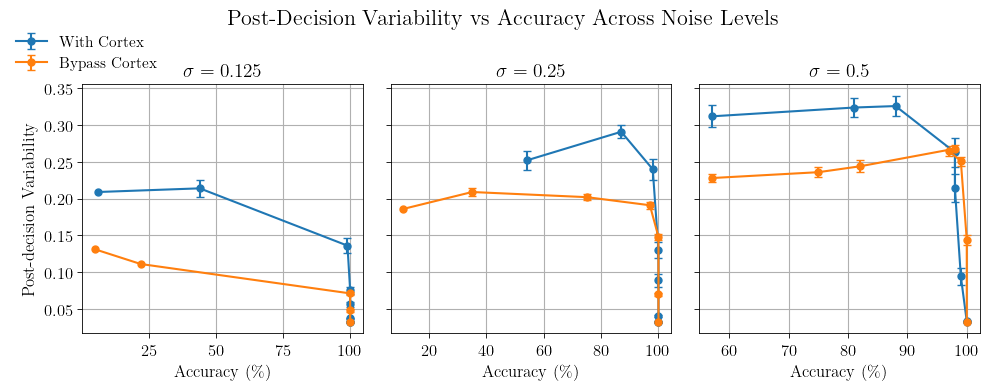

Saved: ..\..\figures\cortical dynamics\suite1\Post-Decision Variability vs Accuracy.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Post-Decision Variability vs Accuracy.png


In [38]:
# ==== Plotting ====
fig, ax = plt.subplots(1, 3,  figsize= figure_size('single'),  sharey = 'row')


# Post-decision variability vs accuracy
ax[0].errorbar(x = acc_0125, y = pdv_0125, yerr = pdv_err_0125, fmt='o-', capsize = 3, markersize = 5, label='With Cortex')
ax[0].errorbar(x = acc_0125_bypass, y = pdv_0125_bypass, yerr = pdv_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5, label='Bypass Cortex')
ax[0].set_title('$\sigma = 0.125$')
ax[0].set_ylabel('Post-decision Variability')
ax[0].grid(which = 'both')
ax[0].set_xlabel('Accuracy (\%)')

ax[1].errorbar(x = acc_025, y = pdv_025, yerr = pdv_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[1].errorbar(x = acc_025_bypass, y = pdv_025_bypass, yerr = pdv_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1].set_title('$\sigma = 0.25$')
ax[1].grid(which = 'both')
ax[1].set_xlabel('Accuracy (\%)')

ax[2].errorbar(x = acc_05, y = pdv_05, yerr = pdv_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[2].errorbar(x = acc_05_bypass, y = pdv_05_bypass, yerr = pdv_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[2].set_title('$\sigma = 0.5$')
ax[2].grid(which = 'both')
ax[2].set_xlabel('Accuracy (\%)')


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.87), frameon=False)
plt.suptitle('Post-Decision Variability vs Accuracy Across Noise Levels')
plt.tight_layout()
plt.show()

save_plot(fig, 'Post-Decision Variability vs Accuracy', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

For $\sigma = 0.5$, it could also be meaningful to plot the post-decision variability for correct and incorrect decisions separately. Furthermore, the difference in post-decision variability between correct and incorrect decisions is plotted. The trial data is needed for this. Non-parametric bootstrapping is used for finding confidence intervals. Throughout this project, the typical minimal amount of samples required to estimate confidence intervals is set to $n = 30$. However, due to the low amount of incorrect decisions at this noise level, only confidence intervals for `coherence`$ = 1 \%$ can be estimated for incorrect decisions using this value of $n$. Thus, the minimal amount of samples is set to $n = 10$, noting that confidence intervals may be somewhat inaccurate for $3\%$ and $5 \%$ coherence.

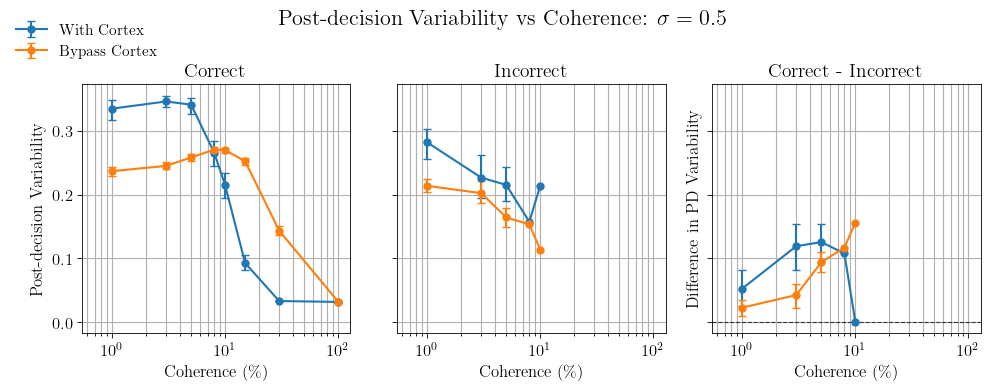

Saved: ..\..\figures\cortical dynamics\suite1\PD Variability Split.pdf
Saved: ..\..\figures\cortical dynamics\suite1\PD Variability Split.png


In [39]:
# - Extract trial data for sigma = 0.5 -
df_trial_05 = trial_data[trial_data['stim_info.noise_std'] == 0.5]
df_trial_05_bypass = trial_data_bypass[trial_data_bypass['stim_info.noise_std'] == 0.5]


# - Helper functions for extracting post-decision variability by coherence and outcome -
def pdv_by_coherence(df, outcome, min_n=10):
    rng = default_rng(1)
    rows = []

    for coherence, group in df[df['decision_info.Outcome'] == outcome].groupby('stim_info.coherence'):
        ci = bootstrap_ci(
            group['decision_info.PD Variability'],
            statistic='mean',
            min_n=min_n,
            rng=rng,
        )

        rows.append({
            'coherence': coherence * 100,
            'mean': ci['metric'],
            'ci_low': ci['ci_low'],
            'ci_high': ci['ci_high'],
            'n': len(group),
        })

    return pd.DataFrame(rows).sort_values('coherence')


def pdv_difference_by_coherence(df, min_n=10):
    rng = default_rng(1)
    rows = []

    for coherence, group in df.groupby('stim_info.coherence'):
        pdv_correct = group[group['decision_info.Outcome'] == 'Correct Decision']['decision_info.PD Variability']
        pdv_wrong = group[group['decision_info.Outcome'] == 'Wrong Decision']['decision_info.PD Variability']

        ci = bootstrap_difference_ci(
            pdv_correct,
            pdv_wrong,
            statistic='mean',
            paired=False,
            min_n=min_n,
            rng=rng,
        )

        rows.append({
            'coherence': coherence * 100,
            'difference': ci['metric'],
            'ci_low': ci['ci_low'],
            'ci_high': ci['ci_high'],
            'n_correct': len(pdv_correct),
            'n_wrong': len(pdv_wrong),
        })

    return pd.DataFrame(rows).sort_values('coherence')


def plot_pdv(axis, stats, label):
    if stats.empty:
        return

    yerr = np.vstack([
        stats['mean'] - stats['ci_low'],
        stats['ci_high'] - stats['mean'],
    ])

    axis.errorbar(
        x=stats['coherence'],
        y=stats['mean'],
        yerr=yerr,
        fmt='o-',
        capsize=3,
        markersize=5,
        label=label,
    )


def plot_pdv_difference(axis, stats, label):
    if stats.empty:
        return

    yerr = np.vstack([
        stats['difference'] - stats['ci_low'],
        stats['ci_high'] - stats['difference'],
    ])

    axis.errorbar(
        x=stats['coherence'],
        y=stats['difference'],
        yerr=yerr,
        fmt='o-',
        capsize=3,
        markersize=5,
        label=label,
    )

# - Plotting post-decision variability by coherence -
fig, ax = plt.subplots(
    1, 3,
    figsize=(figure_size('single')),
    subplot_kw={'xscale': 'log'},
    sharex=True,
    sharey = True
)

outcomes = ['Correct Decision', 'Wrong Decision']

for axis, outcome in zip(ax[:2], outcomes):
    stats = pdv_by_coherence(df_trial_05, outcome)
    stats_bypass = pdv_by_coherence(df_trial_05_bypass, outcome)

    plot_pdv(axis, stats, 'With Cortex')
    plot_pdv(axis, stats_bypass, 'Bypass Cortex')

    axis.set_xlabel('Coherence (\%)')
    axis.grid(which='both')

diff_stats = pdv_difference_by_coherence(df_trial_05)
diff_stats_bypass = pdv_difference_by_coherence(df_trial_05_bypass)

plot_pdv_difference(ax[2], diff_stats, 'With Cortex')
plot_pdv_difference(ax[2], diff_stats_bypass, 'Bypass Cortex')

ax[0].set_ylabel('Post-decision Variability')
ax[2].set_ylabel('Difference in PD Variability')
ax[0].set_title('Correct')
ax[1].set_title('Incorrect')
ax[2].set_title('Correct - Incorrect')
ax[2].set_xlabel('Coherence (\%)')
ax[2].axhline(0, color='0.2', linestyle='--', linewidth=0.8)
ax[2].grid(which='both')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.0, 0.9), frameon=False)

plt.suptitle(r'Post-decision Variability vs Coherence: $\sigma = 0.5$')
plt.tight_layout()
plt.show()

save_plot(fig, 'PD Variability Split', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))



Extracting the numerical data from the above plot

In [40]:
diff_stats

,coherence,difference,ci_low,ci_high,n_correct,n_wrong
0,1.0,0.052799,0.026131,0.082169,57,43
1,3.0,0.119151,0.082041,0.153178,81,18
2,5.0,0.125670,0.094130,0.154468,88,12
3,8.0,0.107824,NaN,NaN,98,2
4,10.0,0.000423,NaN,NaN,98,2
5,15.0,NaN,NaN,NaN,99,1
6,30.0,NaN,NaN,NaN,100,0
7,100.0,NaN,NaN,NaN,100,0


In [41]:
diff_stats_bypass

,coherence,difference,ci_low,ci_high,n_correct,n_wrong
0,1.0,0.022985,0.010578,0.034565,57,33
1,3.0,0.042699,0.023037,0.060144,75,20
2,5.0,0.093842,0.078025,0.110084,82,15
3,8.0,0.117054,NaN,NaN,98,2
4,10.0,0.155788,NaN,NaN,97,3
5,15.0,NaN,NaN,NaN,99,1
6,30.0,NaN,NaN,NaN,100,0
7,100.0,NaN,NaN,NaN,100,0


##### Additional experiments

To get more insight into the dynamics of the model, additional experiments are run for single trials only.

First, decision stability for incorrect decisions is investigated, due to the somewhat counterintuitive observation that incorrect decisions have less post-decision variability than correct decisions, for high noise levels at least.

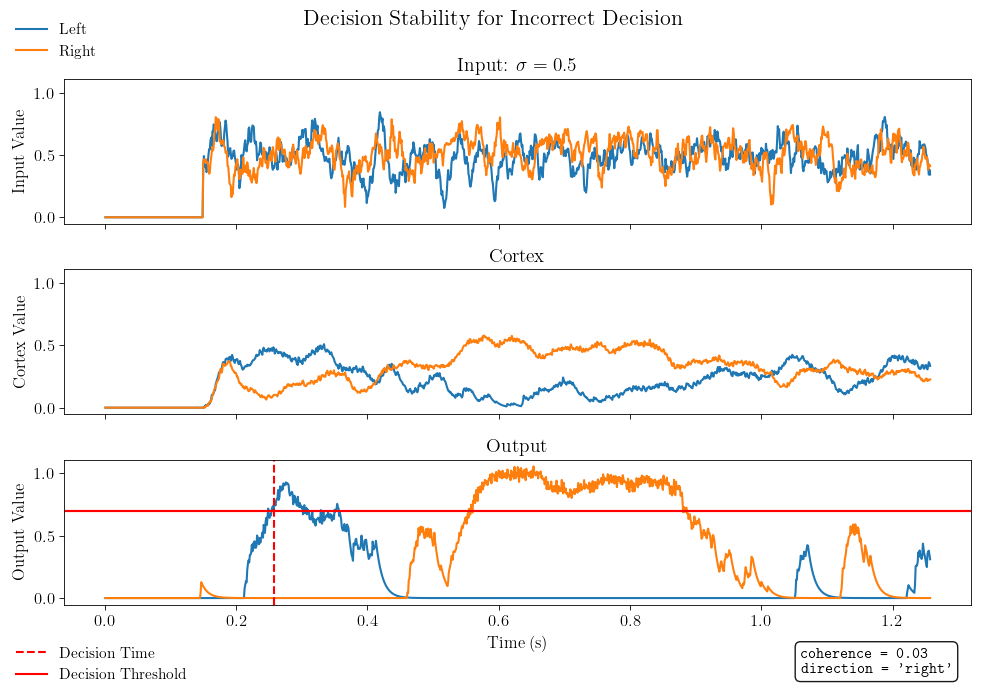

Saved: ..\..\figures\cortical dynamics\suite1\Decision Stability for Wrong Decisions.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Decision Stability for Wrong Decisions.png


In [42]:
# ---- Parameters -----
task_seed = 6 # Task seed is chosen to ensure that an incorrect decision is made
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7 # Default decision threshold, but relevant for the plot in itself
noise_level = 0.5 
coherence = 0.03

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
# Task parameters for low noise
task_params = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )

# ---- Run decision-making task ----

task_result = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True
)

# ---- Get decision time ----
decision_time = task_result.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes = task_result.probes



# Time
time = probes['time']

# Input, cortex and output probes
input_probe = probes['input']
cortex_probe = probes['cortex']
output_probe = probes['output']

# ---- Plot ----
fig, ax = plt.subplots(3, 1, figsize=figure_size('double'), sharex = 'col', sharey = True)

Left, = ax[0].plot(time, input_probe[:,0], label = 'Left')
Right, = ax[0].plot(time, input_probe[:,1], label = 'Right')
ax[0].set_title(f'Input: $\sigma = {noise_level}$')

ax[1].plot(time, cortex_probe[:,0])
ax[1].plot(time, cortex_probe[:,1])
ax[1].set_title('Cortex')

ax[2].plot(time, output_probe[:,0])
ax[2].plot(time, output_probe[:,1])
ax[2].axhline(decision_threshold, color='r', linestyle='-')
ax[2].set_title('Output')



# - Set axes labels -
# x-axis
ax[2].set_xlabel('Time (s)')
# y-axis
ax[0].set_ylabel('Input Value')
ax[1].set_ylabel('Cortex Value')
ax[2].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[2].axvline(decision_time, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[2].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}" "\n"
    rf" \texttt{{direction = 'right'}}"
)

fig.text(
    0.96, 0.07,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Decision Stability for Incorrect Decision')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Decision Stability for Wrong Decisions', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

From the accuracy plots, it appears that accuracy improves at increased noise levels. This, however, is due to more unstable and erratic decision, increasing the chance that the output value may reach the decision threshold. This can be demonstrated by running two decision-making trials, one for $\sigma = 0.125$ and one for $\sigma = 0.25$. The seed will be chosen carefully such that the output reaches the decision threshold for the high noise, but not for low noise.

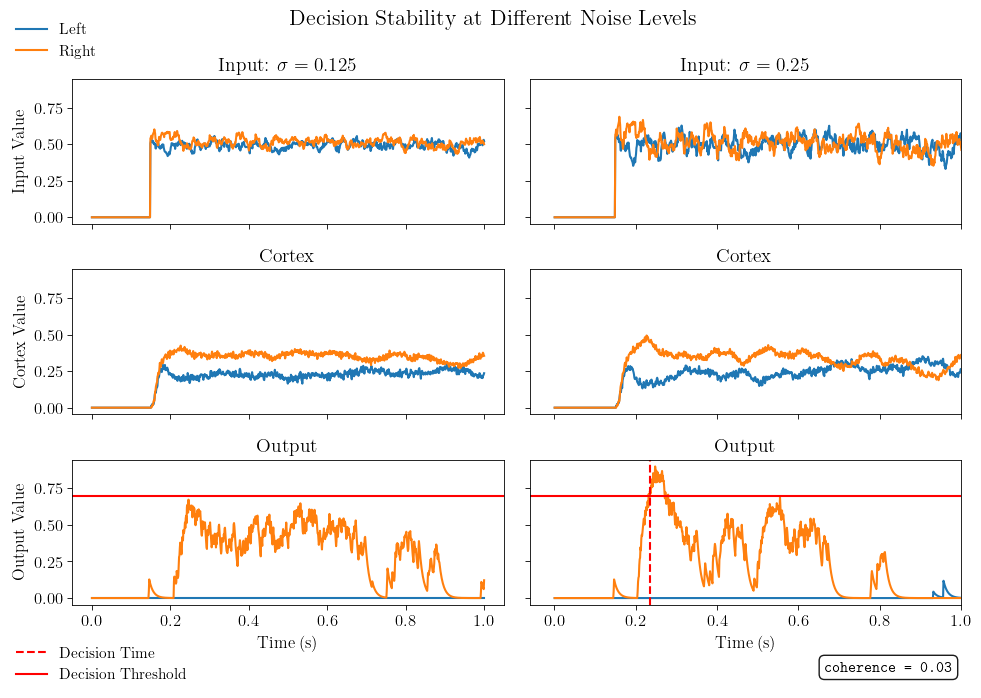

Saved: ..\..\figures\cortical dynamics\suite1\Decision Stability.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Decision Stability.png


In [43]:
# ---- Parameters -----
task_seed = 24 # A task seed is found, such that the model does not make a decision for low noise, but does for high noise.
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.03

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
# Task parameters for low noise
task_params_low = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = 0.125
    )
# Task parameter for high noise
task_params_high = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = 0.25
    )

# ---- Run decision-making task ----

# Low noise
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params_low,
    trial_params = trial_params,
    return_probes = True
)
# High noise
task_result_high = run_task(
    model_params = model_parameters,
    dots_params = task_params_high,
    trial_params = trial_params,
    return_probes = True
)

# ---- Get decision time for high noise condition ----
decision_time_high = task_result_high.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes_low= task_result_low.probes
probes_high= task_result_high.probes


# Time
time_low = probes_low['time']
time_high = probes_high['time']

# Input, cortex and output probes
input_probe_low = probes_low['input']
cortex_probe_low = probes_low['cortex']
output_probe_low = probes_low['output']

input_probe_high = probes_high['input']
cortex_probe_high = probes_high['cortex']
output_probe_high = probes_high['output']

# ---- Plot ----
fig, ax = plt.subplots(3, 2, figsize=figure_size('double'), sharex = 'col', sharey = True)

# Low noise
Left, = ax[0,0].plot(time_low, input_probe_low[:,0], label = 'Left')
Right, = ax[0,0].plot(time_low, input_probe_low[:,1], label = 'Right')
ax[0,0].set_title('Input: $\sigma = 0.125$')

ax[1,0].plot(time_low, cortex_probe_low[:,0])
ax[1,0].plot(time_low, cortex_probe_low[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time_low, output_probe_low[:,0])
ax[2,0].plot(time_low, output_probe_low[:,1])
ax[2,0].axhline(decision_threshold, color='r', linestyle='-')
ax[2,0].set_title('Output')

# High Noise
ax[0,1].plot(time_high, input_probe_high[:,0])
ax[0,1].plot(time_high, input_probe_high[:,1])
ax[0,1].set_title('Input: $\sigma = 0.25$')

ax[1,1].plot(time_high, cortex_probe_high[:,0])
ax[1,1].plot(time_high, cortex_probe_high[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_high, output_probe_high[:,0])
ax[2,1].plot(time_high, output_probe_high[:,1])
ax[2,1].set_title('Output')
ax[2,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[2,1].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[2,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}"

)

fig.text(
    0.96, 0.05,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Decision Stability at Different Noise Levels')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Decision Stability', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

### Difference in Left and Right Accuracy

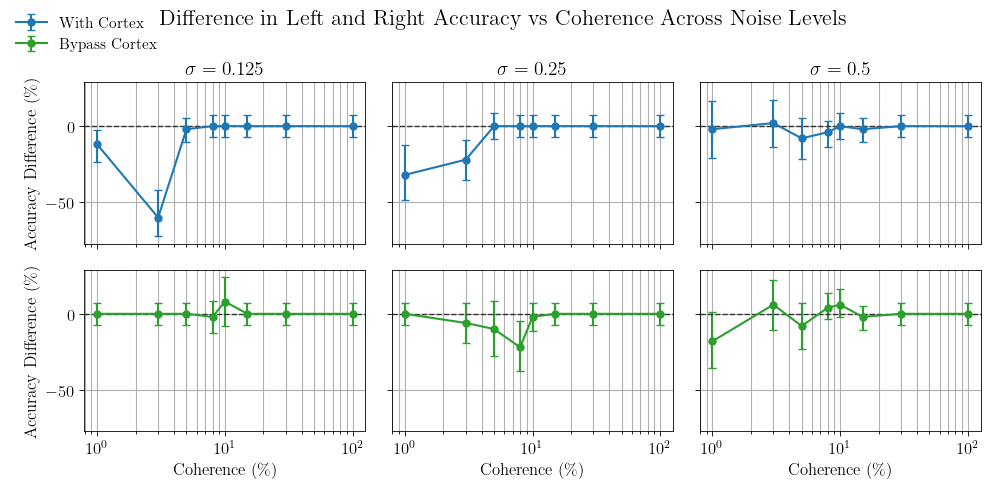

Saved: ..\..\figures\cortical dynamics\suite1\Difference in Left and Right Accuracy vs Coherence.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Difference in Left and Right Accuracy vs Coherence.png


In [44]:
# ==== Get mean and confidence intervals for each noise level ====
# --- With Cortex ---
acc_diff_0125, acc_diff_err_0125_left = get_CI(df_0125, metric='Accuracy Difference (%)') 
acc_diff_025, acc_diff_err_025_left = get_CI(df_025, metric='Accuracy Difference (%)') 
acc_diff_05, acc_diff_err_05_left = get_CI(df_05, metric='Accuracy Difference (%)') 


# --- Without Cortex ---
acc_diff_0125_bypass, acc_diff_err_0125_left_bypass = get_CI(df_0125_bypass, metric='Accuracy Difference (%)') 
acc_diff_025_bypass, acc_diff_err_025_left_bypass = get_CI(df_025_bypass, metric='Accuracy Difference (%)') 
acc_diff_05_bypass, acc_diff_err_05_left_bypass = get_CI(df_05_bypass, metric='Accuracy Difference (%)') 


# ==== Plotting ====
fig, ax = plt.subplots(2, 3,  figsize=(10, 5), subplot_kw={"xscale": "log"}, sharex = 'col', sharey = True)


# With cortex
ax[0, 0].errorbar(x = coherences, y = acc_diff_0125, yerr = acc_diff_err_0125_left, fmt='o-', capsize = 3, markersize = 5, label='With Cortex')
ax[0, 0].set_title('$\sigma = 0.125$')
ax[0, 0].set_ylabel('Accuracy Difference (\%)')
ax[0, 0].grid(which = 'both')
ax[0,0].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[0,1].errorbar(x = coherences, y = acc_diff_025, yerr = acc_diff_err_025_left, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].set_title('$\sigma = 0.25$')
ax[0,1].grid(which = 'both')
ax[0,1].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[0, 2].errorbar(x = coherences, y = acc_diff_05, yerr = acc_diff_err_05_left, fmt='o-', capsize = 3, markersize = 5)
ax[0, 2].set_title('$\sigma = 0.5$')
ax[0, 2].grid(which = 'both')
ax[0, 2].axhline(0, color='0.2', linestyle='--', linewidth=1)

# Bypass cortex
ax[1, 0].errorbar(x = coherences, y = acc_diff_0125_bypass, yerr = acc_diff_err_0125_left_bypass, fmt='o-', capsize = 3, markersize = 5, label='Bypass Cortex', color = 'tab:green')
ax[1, 0].set_ylabel('Accuracy Difference (\%)')
ax[1, 0].grid(which = 'both')
ax[1, 0].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[1, 1].errorbar(x = coherences, y = acc_diff_025_bypass, yerr = acc_diff_err_025_left_bypass, fmt='o-', capsize = 3, markersize = 5, color = 'tab:green')
ax[1, 1].grid(which = 'both')
ax[1, 1].axhline(0, color='0.2', linestyle='--', linewidth=1)

ax[1, 2].errorbar(x = coherences, y = acc_diff_05_bypass, yerr = acc_diff_err_05_left_bypass, fmt='o-', capsize = 3, markersize = 5, color = 'tab:green')
ax[1, 2].grid(which = 'both')
ax[1, 2].axhline(0, color='0.2', linestyle='--', linewidth=1)

# x-axis labels
ax[1, 0].set_xlabel('Coherence (\%)')
ax[1, 1].set_xlabel('Coherence (\%)')
ax[1, 2].set_xlabel('Coherence (\%)')

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.93), frameon=False)
plt.suptitle('Difference in Left and Right Accuracy vs Coherence Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Difference in Left and Right Accuracy vs Coherence', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

The model appears to favor right input. The left and right inputs are independent; to ensure that the difference is actually due to bias and not difference in stochastic realization, two trials are run, one left and one right trial, to see if there is a bias present. The two trials use the same seed, but the left and right seeds are interchanged, to ensure that any difference between the two trials is solely due to bias and not stochastic realization

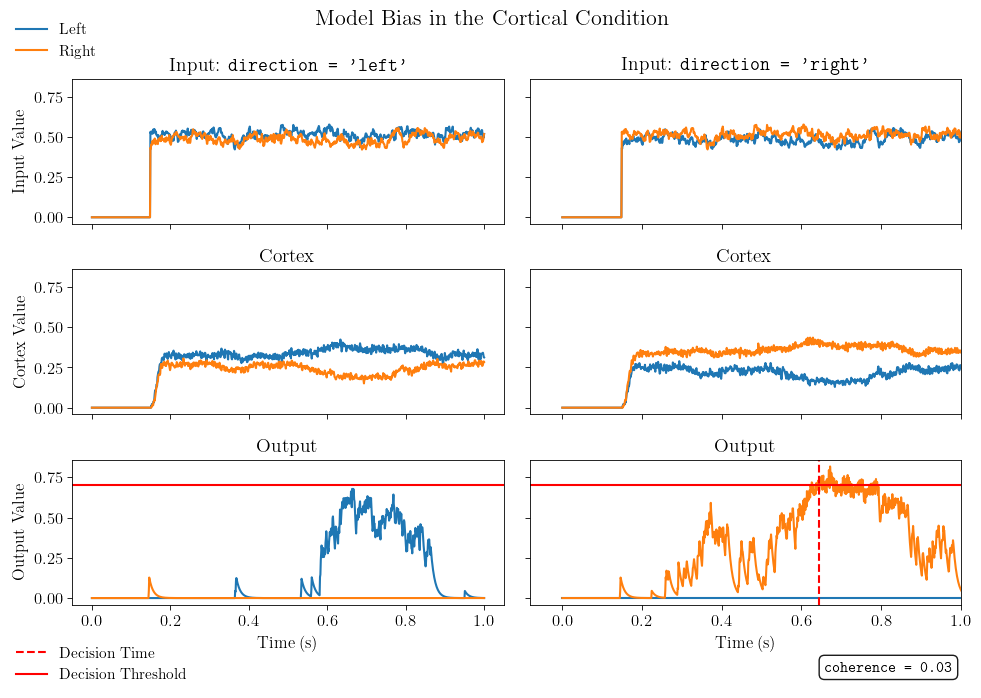

Saved: ..\..\figures\cortical dynamics\suite1\Model Bias With Cortex.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Model Bias With Cortex.png


In [45]:
# ---- Parameters -----
task_seed = 4 # A task seed is found, such that the model makes a decision for right stimulus, but not left
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.03


bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
# Task parameters for left stimulus
task_params_left = DotsParams(
    direction = 'left', 
    strength = 1,
    coherence = coherence,
    noise_std = 0.125
    )
# Task parameters for right stimulus
task_params_right = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = 0.125
    )

# ---- Run decision-making task ----

# Left Input
task_result_left = run_task(
    model_params = model_parameters,
    dots_params = task_params_left,
    trial_params = trial_params,
    return_probes = True
)
# Right Input
task_result_right = run_task(
    model_params = model_parameters,
    dots_params = task_params_right,
    trial_params = trial_params,
    swap_seeds = True, # Swap seeds to so that the difference in decision is due to the direction of the stimulus, not the specific noise realization.
    return_probes = True
)

# ---- Get decision time for right trial ----
decision_time_right = task_result_right.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes_left= task_result_left.probes
probes_right= task_result_right.probes


# Time
time_left = probes_left['time']
time_right = probes_right['time']

# Input, cortex and output probes
input_probe_left = probes_left['input']
cortex_probe_left = probes_left['cortex']
output_probe_left = probes_left['output']

input_probe_right = probes_right['input']
cortex_probe_right = probes_right['cortex']
output_probe_right = probes_right['output']

# ---- Plot ----
fig, ax = plt.subplots(3, 2, figsize=figure_size('double'), sharex = 'col', sharey = True)

# Left Trial
Left, = ax[0,0].plot(time_left, input_probe_left[:,0], label = 'Left')
Right, = ax[0,0].plot(time_left, input_probe_left[:,1], label = 'Right')
ax[0,0].set_title(r"Input: \texttt{{direction = 'left'}}")

ax[1,0].plot(time_left, cortex_probe_left[:,0])
ax[1,0].plot(time_left, cortex_probe_left[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time_left, output_probe_left[:,0])
ax[2,0].plot(time_left, output_probe_left[:,1])
ax[2,0].axhline(decision_threshold, color='r', linestyle='-')
ax[2,0].set_title('Output')

# Right Trial
ax[0,1].plot(time_right, input_probe_right[:,0])
ax[0,1].plot(time_right, input_probe_right[:,1])
ax[0,1].set_title(r"Input: \texttt{{direction = 'right'}}")

ax[1,1].plot(time_right, cortex_probe_right[:,0])
ax[1,1].plot(time_right, cortex_probe_right[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_right, output_probe_right[:,0])
ax[2,1].plot(time_right, output_probe_right[:,1])
ax[2,1].set_title('Output')
ax[2,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[2,1].axvline(decision_time_right, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[2,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}"

)

fig.text(
    0.96, 0.05,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Model Bias in the Cortical Condition')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Model Bias With Cortex', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

The cortex does appear to a source of bias. To see whether bias is present in the basal ganglia-thalamic system alone, the same task is run without the cortex.

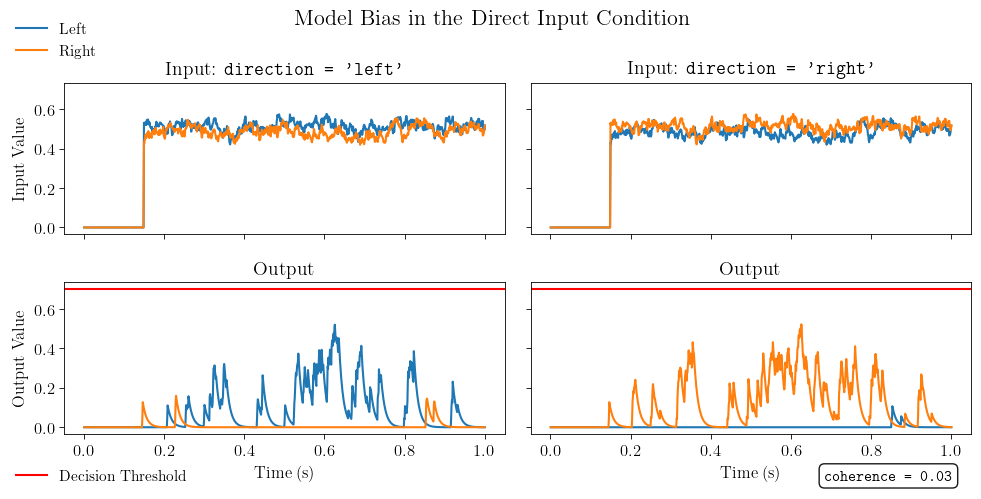

Saved: ..\..\figures\cortical dynamics\suite1\Model Bias Without Cortex.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Model Bias Without Cortex.png


In [46]:
# ---- Parameters -----
task_seed = 4 # The task seed is the same as before.
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.03
noise_level = 0.125


bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
# Task parameters for left input
task_params_left = DotsParams(
    direction = 'left', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )
# Task parameter for right input
task_params_right = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )

# ---- Run decision-making task ----

# Low noise
task_result_left = run_task(
    model_params = model_parameters,
    dots_params = task_params_left,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = True
)
# Medium noise
task_result_right = run_task(
    model_params = model_parameters,
    dots_params = task_params_right,
    trial_params = trial_params,
    swap_seeds = True, # Swap seeds to so that the difference in decision is due to the direction of the stimulus, not the specific noise realization.
    return_probes = True,
    bypass_cortex = True
)

# ---- Extract relevant probe data ----
probes_left= task_result_left.probes
probes_right= task_result_right.probes


# Time
time_left = probes_left['time']
time_right = probes_right['time']

# Input probe
# For the input probe, I have to reuse the probes from the previous runs, since when bypassing the cortex, the input probe is not recorded. This is somewhat inelegant,
# but fixing the issue requires restructuring the model code, which is not worth it for this specific issue.
# This will not affect the results, since the input is the same for both runs.
input_probe_bypass_left = input_probe_left
input_probe_bypass_right = input_probe_right[:1000] # Only take the first 1000 time points, to match the length of the input probe in the bypass condition.

# Output probe
output_probe_right = probes_right['output']
output_probe_left = probes_left['output']

# ---- Plot ----
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharex = 'col', sharey = True)

# Left trial
Left, = ax[0,0].plot(time_left, input_probe_bypass_left[:,0], label = 'Left')
Right, = ax[0,0].plot(time_left, input_probe_bypass_left[:,1], label = 'Right')
ax[0,0].set_title(r"Input: \texttt{{direction = 'left'}}")

ax[1,0].plot(time_left, output_probe_left[:,0])
ax[1,0].plot(time_left, output_probe_left[:,1])
ax[1,0].axhline(decision_threshold, color='r', linestyle='-')
ax[1,0].set_title('Output')

# Right Trial
ax[0,1].plot(time_right, input_probe_bypass_right[:,0])
ax[0,1].plot(time_right, input_probe_bypass_right[:,1])
ax[0,1].set_title(r"Input: \texttt{{direction = 'right'}}")

ax[1,1].plot(time_right, output_probe_right[:,0])
ax[1,1].plot(time_right, output_probe_right[:,1])
ax[1,1].set_title('Output')


# - Set axes labels -
# x-axis
ax[1,0].set_xlabel('Time (s)')
ax[1,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[1,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
threshold_line = ax[1,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.005),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}"

)

fig.text(
    0.96, 0.06,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Model Bias in the Direct Input Condition')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Model Bias Without Cortex', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

From the accuracy difference plots, it seems that bias becomes less prominent at higher noise levels. Trials are run in the same manner as above, but for $\sigma = 0.5$

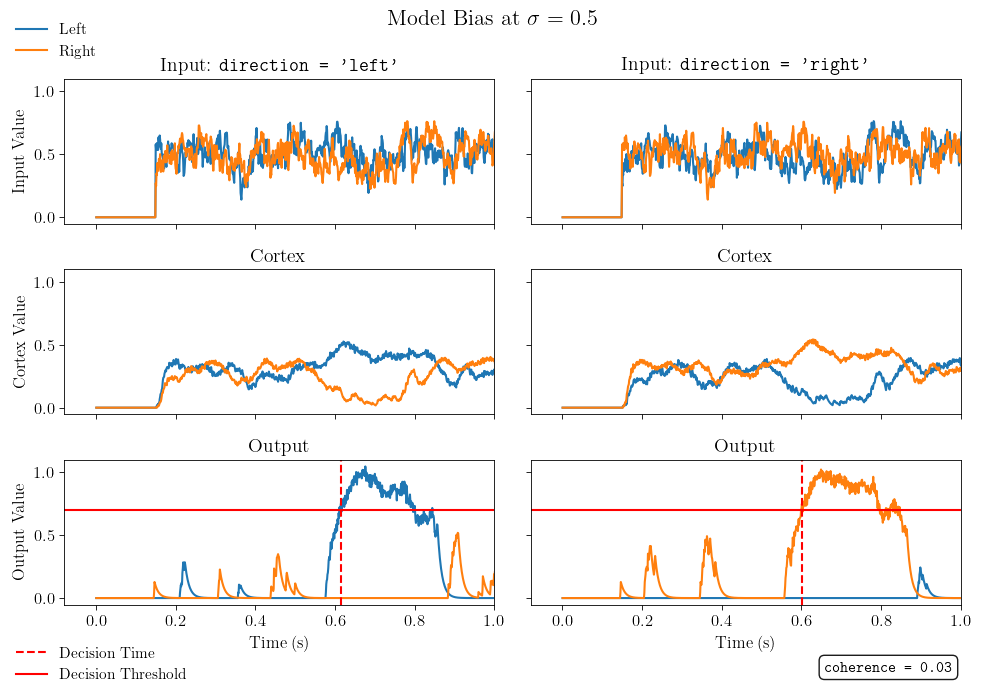

Saved: ..\..\figures\cortical dynamics\suite1\Model Bias High Noise.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Model Bias High Noise.png


In [47]:
# ---- Parameters -----
task_seed = 4 # Task seed is the same as before, to compare the same noise realization across noise levels.
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.03
noise_level = 0.5


bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
# Task parameters for low noise
task_params_left = DotsParams(
    direction = 'left', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )
# Task parameters for medium noise
task_params_right = DotsParams(
    direction = 'right', 
    strength = 1,
    coherence = coherence,
    noise_std = noise_level
    )

# ---- Run decision-making task ----

# Left Input
task_result_left = run_task(
    model_params = model_parameters,
    dots_params = task_params_left,
    trial_params = trial_params,
    return_probes = True
)
# Right Input
task_result_right = run_task(
    model_params = model_parameters,
    dots_params = task_params_right,
    trial_params = trial_params,
    swap_seeds = True, # Swap seeds to so that the difference in decision is due to the direction of the stimulus, not the specific noise realization.
    return_probes = True
)

# ---- Get decision time for right trial ----
decision_time_left = task_result_left.decision_info['RT (ms)']/1000 + t_warmup
decision_time_right = task_result_right.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes_left= task_result_left.probes
probes_right= task_result_right.probes


# Time
time_left = probes_left['time']
time_right = probes_right['time']

# Input, cortex and output probes
input_probe_left = probes_left['input']
cortex_probe_left = probes_left['cortex']
output_probe_left = probes_left['output']

input_probe_right = probes_right['input']
cortex_probe_right = probes_right['cortex']
output_probe_right = probes_right['output']

# ---- Plot ----
fig, ax = plt.subplots(3, 2, figsize=figure_size('double'), sharex = 'col', sharey = True)

# Left Trial
Left, = ax[0,0].plot(time_left, input_probe_left[:,0], label = 'Left')
Right, = ax[0,0].plot(time_left, input_probe_left[:,1], label = 'Right')
ax[0,0].set_title(r"Input: \texttt{{direction = 'left'}}")

ax[1,0].plot(time_left, cortex_probe_left[:,0])
ax[1,0].plot(time_left, cortex_probe_left[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time_left, output_probe_left[:,0])
ax[2,0].plot(time_left, output_probe_left[:,1])
ax[2,0].axhline(decision_threshold, color='r', linestyle='-')
ax[2,0].set_title('Output')
ax[2,0].set_xlim(right = 1)

# Right Trial
ax[0,1].plot(time_right, input_probe_right[:,0])
ax[0,1].plot(time_right, input_probe_right[:,1])
ax[0,1].set_title(r"Input: \texttt{{direction = 'right'}}")

ax[1,1].plot(time_right, cortex_probe_right[:,0])
ax[1,1].plot(time_right, cortex_probe_right[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_right, output_probe_right[:,0])
ax[2,1].plot(time_right, output_probe_right[:,1])
ax[2,1].set_title('Output')
ax[2,1].set_xlim(right = 1)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line_left = ax[2,0].axvline(decision_time_left, color='r', linestyle='--', label='Decision Time')
decision_line_right = ax[2,1].axvline(decision_time_right, color='r', linestyle='--')
threshold_line = ax[2,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}"

)

fig.text(
    0.96, 0.05,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle(f'Model Bias at $\sigma = {noise_level}$')
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()

save_plot(fig, 'Model Bias High Noise', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

### Reaction Times

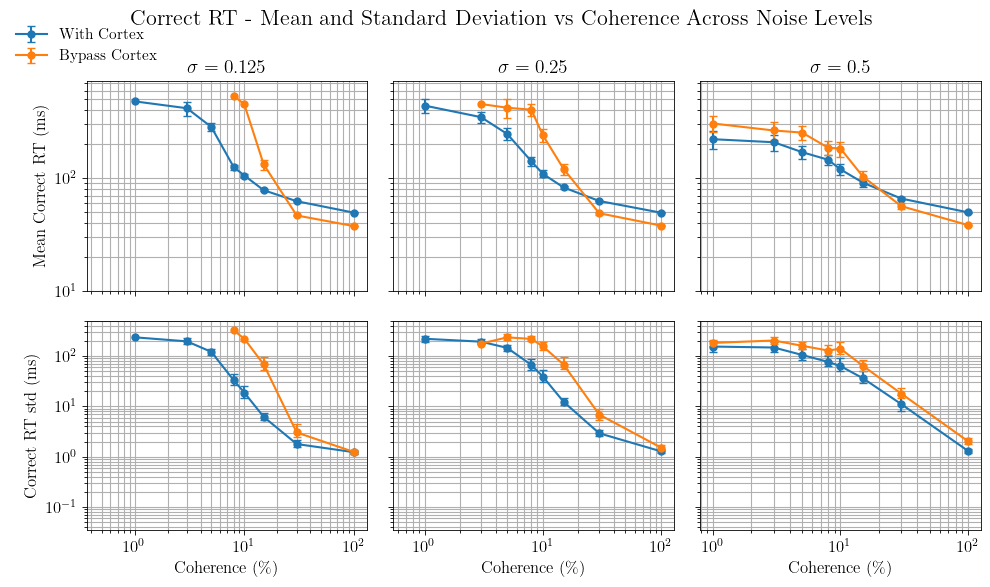

Saved: ..\..\figures\cortical dynamics\suite1\Correct RT - Mean and Standard Deviation vs Coherence.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Correct RT - Mean and Standard Deviation vs Coherence.png


In [48]:
## ==== Get RT mean and std along with confidence intervals for each noise level ====
# --- RT Mean ---
RT_mean_0125, RT_err_0125 = get_CI(df_0125, metric='Mean Correct RT (ms)') 
RT_mean_025, RT_err_025 = get_CI(df_025, metric='Mean Correct RT (ms)') 
RT_mean_05, RT_err_05 = get_CI(df_05, metric='Mean Correct RT (ms)') 

RT_mean_0125_bypass, RT_mean_err_0125_bypass = get_CI(df_0125_bypass, metric='Mean Correct RT (ms)') 
RT_mean_025_bypass, RT_mean_err_025_bypass = get_CI(df_025_bypass, metric='Mean Correct RT (ms)') 
RT_mean_05_bypass, RT_mean_err_05_bypass = get_CI(df_05_bypass, metric='Mean Correct RT (ms)') 

# --- RT std ---
RT_std_0125, RT_std_err_0125 = get_CI(df_0125, metric='Correct RT std (ms)') 
RT_std_025, RT_std_err_025 = get_CI(df_025, metric='Correct RT std (ms)') 
RT_std_05, RT_std_err_05 = get_CI(df_05, metric='Correct RT std (ms)') 

RT_std_0125_bypass, RT_std_err_0125_bypass = get_CI(df_0125_bypass, metric='Correct RT std (ms)') 
RT_std_025_bypass, RT_std_err_025_bypass = get_CI(df_025_bypass, metric='Correct RT std (ms)') 
RT_std_05_bypass, RT_std_err_05_bypass = get_CI(df_05_bypass, metric='Correct RT std (ms)') 


# ==== Plotting ====
fig, ax = plt.subplots(2, 3,  figsize=(10,6), subplot_kw={"xscale": "log", "yscale": "log"}, sharex = 'col', sharey = 'row')

# RT Mean
ax[0,0].errorbar(x = coherences, y = RT_mean_0125, yerr = RT_err_0125, fmt='o-', capsize = 3, markersize = 5, label='With Cortex')
ax[0,0].errorbar(x = coherences, y = RT_mean_0125_bypass, yerr = RT_mean_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5, label='Bypass Cortex')
ax[0,0].set_title('$\sigma = 0.125$')
ax[0,0].set_ylabel('Mean Correct RT (ms)')
ax[0,0].grid(which = 'both')
ax[0,0].set_ylim(bottom=10)  # Set lower limit for log scale

ax[0,1].errorbar(x = coherences, y = RT_mean_025, yerr = RT_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].errorbar(x = coherences, y = RT_mean_025_bypass, yerr = RT_mean_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].set_title('$\sigma = 0.25$')
ax[0,1].grid(which = 'both')

ax[0,2].errorbar(x = coherences, y = RT_mean_05, yerr = RT_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].errorbar(x = coherences, y = RT_mean_05_bypass, yerr = RT_mean_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].set_title('$\sigma = 0.5$')
ax[0,2].grid(which = 'both')

# RT std
ax[1,0].errorbar(x = coherences, y = RT_std_0125, yerr = RT_std_err_0125, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].errorbar(x = coherences, y = RT_std_0125_bypass, yerr = RT_std_err_0125_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].set_xlabel('Coherence (\%)')
ax[1,0].set_ylabel('Correct RT std (ms)')
ax[1,0].grid(which = 'both')

ax[1,1].errorbar(x = coherences, y = RT_std_025, yerr = RT_std_err_025, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].errorbar(x = coherences, y = RT_std_025_bypass, yerr = RT_std_err_025_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].set_xlabel('Coherence (\%)')
ax[1,1].grid(which = 'both')

ax[1,2].errorbar(x = coherences, y = RT_std_05, yerr = RT_std_err_05, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].errorbar(x = coherences, y = RT_std_05_bypass, yerr = RT_std_err_05_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].set_xlabel('Coherence (\%)')
ax[1,2].grid(which = 'both')


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.92), frameon=False)
plt.suptitle('Correct RT - Mean and Standard Deviation vs Coherence Across Noise Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Correct RT - Mean and Standard Deviation vs Coherence', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

Extracting numerical values for reaction statistics for $\sigma = 0.125$ with the cortex

In [49]:
noise = 0.125

RT_stats_table = summary_stats.loc[
    np.isclose(summary_stats["noise_std"], noise),
    [
        "coherence",
        "Mean Correct RT (ms)",
        "Mean Correct RT CI Margin (ms)",
        "Correct RT std (ms)",
        "Correct RT std CI Low (ms)",
        "Correct RT std CI High (ms)",
    ],
].copy()

RT_stats_table["Coherence"] = RT_stats_table["coherence"] * 100
RT_stats_table["RT Mean"] = RT_stats_table["Mean Correct RT (ms)"]
RT_stats_table["RT Mean CI Low"] = (
    RT_stats_table["Mean Correct RT (ms)"]
    - RT_stats_table["Mean Correct RT CI Margin (ms)"]
)
RT_stats_table["RT Mean CI High"] = (
    RT_stats_table["Mean Correct RT (ms)"]
    + RT_stats_table["Mean Correct RT CI Margin (ms)"]
)
RT_stats_table["RT std"] = RT_stats_table["Correct RT std (ms)"]
RT_stats_table["RT std CI Low"] = RT_stats_table["Correct RT std CI Low (ms)"]
RT_stats_table["RT std CI High"] = RT_stats_table["Correct RT std CI High (ms)"]

RT_stats_table = (
    RT_stats_table[
        [
            "Coherence",
            "RT Mean",
            "RT Mean CI Low",
            "RT Mean CI High",
            "RT std",
            "RT std CI Low",
            "RT std CI High",
        ]
    ]
    .sort_values("Coherence")
    .round(2)
    .reset_index(drop=True)
)

display(RT_stats_table)


,Coherence,RT Mean,RT Mean CI Low,RT Mean CI High,RT std,RT std CI Low,RT std CI High
0,1.0,481.50,NaN,NaN,237.70,NaN,NaN
1,3.0,418.27,358.25,478.29,197.42,174.61,225.12
2,5.0,285.28,260.93,309.63,122.09,107.05,140.86
3,8.0,125.67,119.07,132.27,33.28,27.00,43.36
4,10.0,105.73,101.99,109.47,18.85,14.84,25.71
5,15.0,78.32,77.09,79.55,6.22,5.41,7.29
6,30.0,62.54,62.19,62.89,1.79,1.53,2.12
7,100.0,49.44,49.20,49.68,1.23,1.14,1.32


It would also be relevant to create a plot directly showing the difference between reaction time statistics with and without the cortex. Log-scaled axes are needed, as the reaction time statistics span a wide range. However, as the reaction time difference statistics may be both both positive and negative, symmetrical log-scaled axes are required.

Trial data is required to calculated the differences. Confidence intervals are calculated through non-parametric bootstrapping.

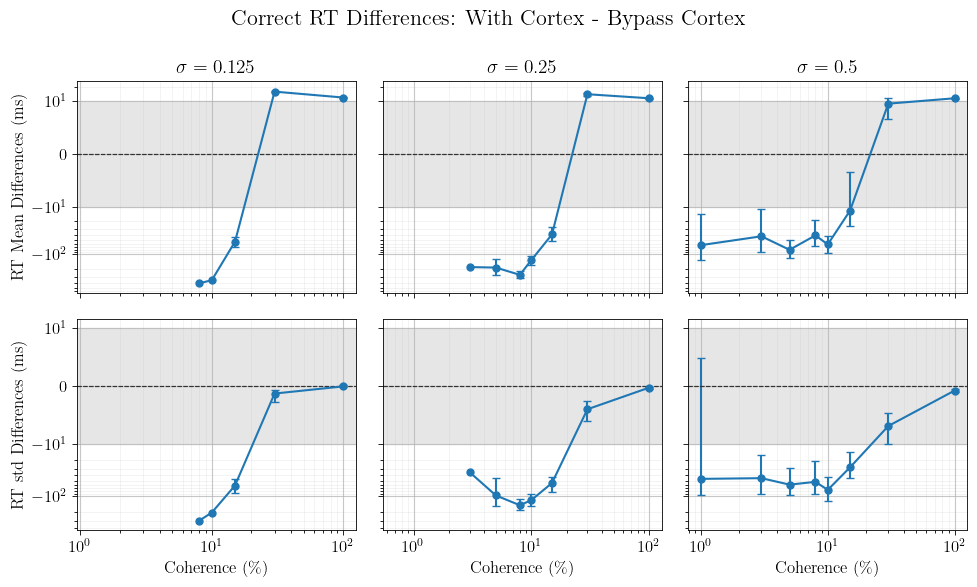

Saved: ..\..\figures\cortical dynamics\suite1\Correct RT Differences.pdf
Saved: ..\..\figures\cortical dynamics\suite1\Correct RT Differences.png


In [50]:
rt_col = "decision_info.RT (ms)"
noise_col = "stim_info.noise_std"
coh_col = "stim_info.coherence"
outcome_col = "decision_info.Outcome"

# - Split data and calculate differences -
def rt_diff_by_noise_and_coherence(statistic, min_n=30, seed=15):
    rng = default_rng(seed)
    rows = []

    for noise in sorted(trial_data[noise_col].unique()):
        for coherence in sorted(trial_data[coh_col].unique()):
            mask = (
                np.isclose(trial_data[noise_col], noise)
                & np.isclose(trial_data[coh_col], coherence)
                & trial_data[outcome_col].eq("Correct Decision")
            )
            mask_bypass = (
                np.isclose(trial_data_bypass[noise_col], noise)
                & np.isclose(trial_data_bypass[coh_col], coherence)
                & trial_data_bypass[outcome_col].eq("Correct Decision")
            )

            ci = bootstrap_difference_ci(
                trial_data.loc[mask, rt_col],
                trial_data_bypass.loc[mask_bypass, rt_col],
                statistic=statistic,
                paired=True,
                min_n=min_n,
                rng=rng,
            )

            rows.append({
                "noise_std": noise,
                "coherence": coherence * 100,
                "difference": ci["metric"],
                "ci_low": ci["ci_low"],
                "ci_high": ci["ci_high"],
            })

    df = pd.DataFrame(rows)
    df["err_low"] = df["difference"] - df["ci_low"]
    df["err_high"] = df["ci_high"] - df["difference"]
    return df


# - Get differences in mean and standard deviation -
RT_mean_diff = rt_diff_by_noise_and_coherence("mean")
RT_std_diff = rt_diff_by_noise_and_coherence("std")

# - Plot -
fig, ax = plt.subplots(2, 3, figsize=(10,6), subplot_kw={"xscale": "log"}, sharex="col", sharey="row",
)

for col, noise in enumerate([0.125, 0.25, 0.5]):
    mean_df = RT_mean_diff[np.isclose(RT_mean_diff["noise_std"], noise)]
    std_df = RT_std_diff[np.isclose(RT_std_diff["noise_std"], noise)]

    ax[0, col].errorbar(
        x=mean_df["coherence"],
        y=mean_df["difference"],
        yerr=np.vstack([mean_df["err_low"], mean_df["err_high"]]),
        fmt="o-",
        capsize=3,
        markersize=5,
    )
    ax[0, col].axhline(0, color="0.2", linestyle="--", linewidth=0.8)
    ax[0, col].set_title(rf"$\sigma = {noise}$")
    ax[0, col].grid(which="both")

    ax[1, col].errorbar(
        x=std_df["coherence"],
        y=std_df["difference"],
        yerr=np.vstack([std_df["err_low"], std_df["err_high"]]),
        fmt="o-",
        capsize=3,
        markersize=5,
    )
    ax[1, col].axhline(0, color="0.2", linestyle="--", linewidth=0.8)
    ax[1, col].set_xlabel("Coherence (\%)")
    ax[1, col].grid(which="both")

ax[0, 0].set_ylabel("RT Mean Differences (ms)")
ax[1, 0].set_ylabel("RT std Differences (ms)")

# Symmetric log-scale
linthresh = 10
for axis in ax.ravel():
    axis.set_yscale("symlog", linthresh=linthresh)

    axis.yaxis.set_major_locator(
        SymmetricalLogLocator(base=10, linthresh=linthresh)
    )
    axis.yaxis.set_minor_locator(
        SymmetricalLogLocator(base=10, linthresh=linthresh, subs=np.arange(2, 10))
    )

    axis.axhspan(-linthresh, linthresh, color="0.9", alpha=1, zorder=0)
    axis.axhline(0, color="0.2", linestyle="--", linewidth=0.8)

    axis.grid(which="major", linewidth=0.8, alpha=0.7)
    axis.grid(which="minor", linewidth=0.4, alpha=0.25)


plt.suptitle("Correct RT Differences: With Cortex - Bypass Cortex")
plt.tight_layout()
plt.show()

save_plot(fig, 'Correct RT Differences', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))


Extract the numerical values from the above plot and make a table. Confidence intervals may have been nice to include, but the table would become too wide.

In [51]:
required_cols = {'noise_std', 'coherence', 'difference'}

if isinstance(globals().get('RT_mean_diff'), pd.DataFrame) and required_cols.issubset(RT_mean_diff.columns):
    RT_mean_diff_long = RT_mean_diff.copy()

if isinstance(globals().get('RT_std_diff'), pd.DataFrame) and required_cols.issubset(RT_std_diff.columns):
    RT_std_diff_long = RT_std_diff.copy()

noise_levels = sorted(
    set(RT_mean_diff_long['noise_std'].dropna().unique())
    | set(RT_std_diff_long['noise_std'].dropna().unique())
)

def _format_noise_level(value):
    return f'{value:.3f}'.rstrip('0').rstrip('.')

def _build_wide_diff_table(df):
    wide = (
        df.pivot_table(
            index='coherence',
            columns='noise_std',
            values='difference',
            aggfunc='first',
        )
        .reindex(columns=noise_levels)
        .sort_index()
        .rename_axis(columns=None)
        .reset_index()
    )

    value_cols = [col for col in wide.columns if col != 'coherence']
    wide[value_cols] = wide[value_cols].round(2)

    if np.allclose(wide['coherence'], np.round(wide['coherence'])):
        wide['coherence'] = wide['coherence'].round().astype(int)

    return wide

class _WideDiffBlock:
    def __init__(self, df, noise_levels):
        self.df = df
        self.noise_levels = noise_levels

    def rename(self, columns=None, *args, **kwargs):
        renamed = self.df.copy()

        if columns and 'difference' in columns:
            stat_name = columns['difference']
            renamed.columns = ['coherence'] + [
                f'{stat_name}_sigma_{_format_noise_level(level)}'
                for level in self.noise_levels
            ]

        return _WideDiffBlock(renamed, self.noise_levels)

    def merge(self, other, on='coherence', how='inner', *args, **kwargs):
        other_df = other.df if isinstance(other, _WideDiffBlock) else other
        return self.df.merge(other_df, on=on, how=how, *args, **kwargs)

class _WideDiffLoc:
    def __init__(self, df, noise_levels):
        self.df = df
        self.noise_levels = noise_levels

    def __getitem__(self, key):
        return _WideDiffBlock(self.df.copy(), self.noise_levels)

class _WideDiffSource:
    def __init__(self, df, noise_levels):
        self.df = df
        self.noise_levels = noise_levels
        self.loc = _WideDiffLoc(df, noise_levels)

    def __getitem__(self, key):
        if key == 'noise_std':
            return pd.Series(-1.0, index=self.df.index, dtype=float)
        if key == 'difference':
            return pd.Series(0.0, index=self.df.index, dtype=float)
        return self.df[key]

mean_wide = _build_wide_diff_table(RT_mean_diff_long)
std_wide = _build_wide_diff_table(RT_std_diff_long)

RT_mean_diff = _WideDiffSource(mean_wide, noise_levels)
RT_std_diff = _WideDiffSource(std_wide, noise_levels)

selected_noise = noise if 'noise' in globals() else 0.125

RT_diff_table = (
    RT_mean_diff.loc[
        np.isclose(RT_mean_diff['noise_std'], selected_noise) & RT_mean_diff['difference'].notna(),
        ['coherence', 'difference'],
    ]
    .rename(columns={'difference': 'mean'})
    .merge(
        RT_std_diff.loc[
            np.isclose(RT_std_diff['noise_std'], selected_noise) & RT_std_diff['difference'].notna(),
            ['coherence', 'difference'],
        ].rename(columns={'difference': 'std'}),
        on='coherence',
        how='inner',
    )
    .sort_values('coherence')
    .reset_index(drop=True)
)

display(RT_diff_table)


,coherence,mean_sigma_0.125,mean_sigma_0.25,mean_sigma_0.5,std_sigma_0.125,std_sigma_0.25,std_sigma_0.5
0,1,NaN,NaN,-64.16,NaN,NaN,-46.48
1,3,NaN,-185.55,-41.78,NaN,-34.69,-45.08
2,5,NaN,-189.86,-80.35,NaN,-96.68,-60.00
3,8,-408.00,-269.96,-39.92,-296.36,-149.18,-53.01
4,10,-349.09,-133.03,-61.99,-206.18,-119.17,-75.64
5,15,-54.37,-38.10,-12.02,-62.42,-55.83,-27.86
6,30,15.79,13.92,9.51,-1.25,-3.97,-6.87
7,100,11.86,11.45,11.44,-0.02,-0.24,-0.74


It would be worth looking at the individual distributions. Only plotting the distribution for $\sigma = 0.125$ with the cortex.

Saved: ..\..\figures\rt\Correct RT.pdf
Saved: ..\..\figures\rt\Correct RT.png


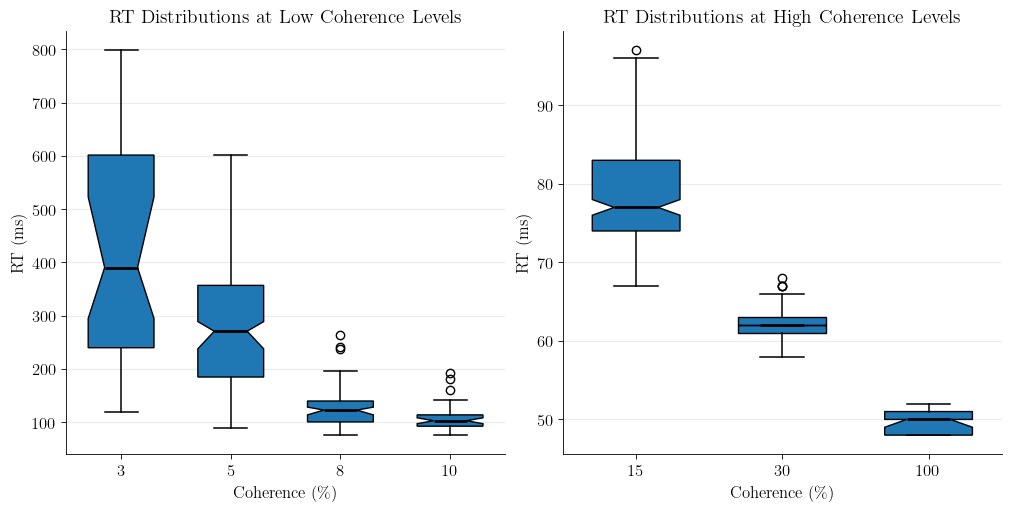

In [52]:
noise = 0.125

rt_col = "decision_info.RT (ms)"
noise_col = "stim_info.noise_std"
group_col = "stim_info.coherence"

plot_df = trial_data[
    np.isclose(trial_data[noise_col], noise)
    & trial_data[rt_col].notna()
    & (trial_data["decision_info.Outcome"] == 'Correct Decision')  
].copy()

levels = sorted(plot_df[group_col].unique())
box_data = [
    plot_df.loc[plot_df[group_col] == level, rt_col].to_numpy()
    for level in levels
]

positions = np.arange(len(levels))

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

ax[0].boxplot(
    box_data[1:5],
    positions=positions[1:5],
    notch = True,
    widths=0.6,
    bootstrap = 10000,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.1),
    capprops=dict(color="black", linewidth=1.1),
)

ax[0].set_xticks(positions[1:5])
ax[0].set_xticklabels([int(level*100) for level in levels[1:5]])
ax[0].set_xlabel("Coherence $(\%)$")
ax[0].set_ylabel("RT (ms)")
ax[0].set_title(f"RT Distributions at Low Coherence Levels")

ax[0].grid(axis="y", alpha=0.25)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

ax[1].boxplot(
    box_data[5:],
    positions=positions[5:],
    notch = True,
    widths=0.6,
    bootstrap = 10000,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.1),
    capprops=dict(color="black", linewidth=1.1),
)

ax[1].set_xticks(positions[5:])
ax[1].set_xticklabels([int(level*100) for level in levels[5:]])
ax[1].set_xlabel("Coherence $(\%)$")
ax[1].set_ylabel("RT (ms)")
ax[1].set_title(f"RT Distributions at High Coherence Levels")

ax[1].grid(axis="y", alpha=0.25)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)


save_plot(fig, 'Correct RT', folder='../../figures/rt', formats=('pdf', 'png'))
plt.show()
